# Traffic Sign Detection with YOLOv8 and Attention Mechanisms

This notebook implements and compares two models for traffic sign detection:
1. **Baseline YOLOv8n** - Standard YOLO model
2. **Attention-Enhanced YOLOv8n** - Custom YOLO with CBAM and Self-Attention mechanisms

## Notebook Structure:
- **Part 1:** Data Preparation & Preprocessing
- **Part 2:** Baseline Model Training & Analysis
- **Part 3:** Attention Model Implementation & Training
- **Part 4:** Comprehensive Model Comparison & Evaluation
- **Part 5:** Real-World Testing & Final Recommendations

---

## Part 1: Data Preparation & Preprocessing

### 1.1 Import Required Libraries

In [1]:
import os
import sys
import time
import json
import shutil
import random
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

### 1.0 Utility Functions Module

Define reusable functions to avoid code repetition throughout the notebook.

In [ ]:
def load_training_results(results_path):
    """Load and clean training results CSV file."""
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()
    return df

def print_training_metrics(results_df, model_name):
    """Print training summary statistics."""
    print(f"{model_name} TRAINING METRICS")
    print(f"Total epochs: {len(results_df)}")
    print(f"Final metrics:")
    print(f"  Box Loss: {results_df['train/box_loss'].iloc[-1]:.4f}")
    print(f"  Class Loss: {results_df['train/cls_loss'].iloc[-1]:.4f}")
    print(f"  DFL Loss: {results_df['train/dfl_loss'].iloc[-1]:.4f}")
    print(f"  Val mAP50: {results_df['metrics/mAP50(B)'].iloc[-1]:.4f}")
    print(f"  Val mAP50-95: {results_df['metrics/mAP50-95(B)'].iloc[-1]:.4f}")

def plot_training_metrics(results_df, model_name):
    """Create 6-panel training visualization."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{model_name} Training Metrics', fontsize=16, fontweight='bold')

    # 1. Training Losses
    ax = axes[0, 0]
    ax.plot(results_df['epoch'], results_df['train/box_loss'], label='Box Loss', linewidth=2)
    ax.plot(results_df['epoch'], results_df['train/cls_loss'], label='Class Loss', linewidth=2)
    ax.plot(results_df['epoch'], results_df['train/dfl_loss'], label='DFL Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Loss', fontweight='bold')
    ax.set_title('Training Losses', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Validation mAP
    ax = axes[0, 1]
    ax.plot(results_df['epoch'], results_df['metrics/mAP50(B)'], 
            label='mAP50', color='green', linewidth=2, marker='o', markersize=3)
    ax.plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], 
            label='mAP50-95', color='blue', linewidth=2, marker='s', markersize=3)
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('mAP', fontweight='bold')
    ax.set_title('Validation mAP Metrics', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. Precision and Recall
    ax = axes[0, 2]
    ax.plot(results_df['epoch'], results_df['metrics/precision(B)'], 
            label='Precision', color='orange', linewidth=2, marker='d', markersize=3)
    ax.plot(results_df['epoch'], results_df['metrics/recall(B)'], 
            label='Recall', color='purple', linewidth=2, marker='^', markersize=3)
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title('Precision & Recall', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. Learning Rate
    ax = axes[1, 0]
    lr_cols = [col for col in results_df.columns if 'lr/pg' in col]
    for i, lr_col in enumerate(lr_cols):
        ax.plot(results_df['epoch'], results_df[lr_col], label=f'LR Group {i}', linewidth=2)
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Learning Rate', fontweight='bold')
    ax.set_title('Learning Rate Schedule', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 5. Combined Loss
    ax = axes[1, 1]
    total_loss = (results_df['train/box_loss'] + results_df['train/cls_loss'] + results_df['train/dfl_loss'])
    ax.plot(results_df['epoch'], total_loss, color='red', linewidth=2, label='Total Loss')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Total Loss', fontweight='bold')
    ax.set_title('Combined Training Loss', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 6. F1 Score
    ax = axes[1, 2]
    precision = results_df['metrics/precision(B)']
    recall = results_df['metrics/recall(B)']
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
    ax.plot(results_df['epoch'], f1, color='teal', linewidth=2, marker='*', markersize=4, label='F1 Score')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('F1 Score', fontweight='bold')
    ax.set_title('F1 Score Progression', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return total_loss

def compare_training_curves(baseline_df, attention_df):
    """Plot side-by-side comparison of training curves."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Training Comparison: Baseline vs Attention-Enhanced Model', fontsize=16, fontweight='bold')

    # 1. Box Loss Comparison
    ax = axes[0, 0]
    ax.plot(baseline_df['epoch'], baseline_df['train/box_loss'], label='Baseline', linewidth=2.5, alpha=0.8, color='blue')
    ax.plot(attention_df['epoch'], attention_df['train/box_loss'], label='Attention', linewidth=2.5, alpha=0.8, color='red')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Box Loss', fontweight='bold')
    ax.set_title('Box Loss Comparison', fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # 2. Class Loss Comparison
    ax = axes[0, 1]
    ax.plot(baseline_df['epoch'], baseline_df['train/cls_loss'], label='Baseline', linewidth=2.5, alpha=0.8, color='blue')
    ax.plot(attention_df['epoch'], attention_df['train/cls_loss'], label='Attention', linewidth=2.5, alpha=0.8, color='red')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Class Loss', fontweight='bold')
    ax.set_title('Class Loss Comparison', fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # 3. mAP50 Comparison
    ax = axes[1, 0]
    ax.plot(baseline_df['epoch'], baseline_df['metrics/mAP50(B)'], 
            label='Baseline', linewidth=2.5, alpha=0.8, color='blue', marker='o', markersize=4, markevery=2)
    ax.plot(attention_df['epoch'], attention_df['metrics/mAP50(B)'], 
            label='Attention', linewidth=2.5, alpha=0.8, color='red', marker='s', markersize=4, markevery=2)
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('mAP50', fontweight='bold')
    ax.set_title('Validation mAP50 Comparison', fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # 4. Total Loss Comparison
    ax = axes[1, 1]
    baseline_total = baseline_df['train/box_loss'] + baseline_df['train/cls_loss'] + baseline_df['train/dfl_loss']
    attention_total = attention_df['train/box_loss'] + attention_df['train/cls_loss'] + attention_df['train/dfl_loss']
    ax.plot(baseline_df['epoch'], baseline_total, label='Baseline', linewidth=2.5, alpha=0.8, color='blue')
    ax.plot(attention_df['epoch'], attention_total, label='Attention', linewidth=2.5, alpha=0.8, color='red')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Total Loss', fontweight='bold')
    ax.set_title('Total Training Loss Comparison', fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def calculate_metrics_lists(metrics_obj, metrics_names=['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1']):
    """Extract metric values from metrics object."""
    f1_score = 2 * (metrics_obj.box.mp * metrics_obj.box.mr) / (metrics_obj.box.mp + metrics_obj.box.mr + 1e-6)
    return [
        metrics_obj.box.map50,
        metrics_obj.box.map,
        metrics_obj.box.mp,
        metrics_obj.box.mr,
        f1_score
    ]

def plot_prediction_comparison(model1, model2, img_paths, model1_name='Baseline', model2_name='Attention', max_images=6):
    """Plot side-by-side predictions from two models."""
    img_paths = img_paths[:max_images]
    fig, axes = plt.subplots(len(img_paths), 2, figsize=(16, 4*len(img_paths)))
    if len(img_paths) == 1:
        axes = axes.reshape(1, -1)

    for idx, img_path in enumerate(img_paths):
        # Model 1 predictions
        results1 = model1.predict(img_path, conf=0.25, verbose=False)
        annotated1 = results1[0].plot()
        annotated1_rgb = cv2.cvtColor(annotated1, cv2.COLOR_BGR2RGB)
        
        # Model 2 predictions
        results2 = model2.predict(img_path, conf=0.25, verbose=False)
        annotated2 = results2[0].plot()
        annotated2_rgb = cv2.cvtColor(annotated2, cv2.COLOR_BGR2RGB)
        
        # Display
        axes[idx, 0].imshow(annotated1_rgb)
        axes[idx, 0].set_title(f"{model1_name} - {os.path.basename(img_path)}\nDetections: {len(results1[0].boxes)}", 
                               fontsize=10, fontweight='bold')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(annotated2_rgb)
        axes[idx, 1].set_title(f"{model2_name} - {os.path.basename(img_path)}\nDetections: {len(results2[0].boxes)}", 
                               fontsize=10, fontweight='bold')
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()

print("Utility functions module loaded!")

Utility functions module loaded!


### 1.2 Define Paths and Create Directory Structure

In [3]:
# For Kaggle environment
# DATA_ROOT = "/kaggle/input/tt100k-2021/tt100k_2021"
# WORK_ROOT = "/kaggle/working/"

# For local environment
DATA_ROOT = "tt100k_2021"
WORK_ROOT = ""

OUT_ROOT = f"{WORK_ROOT}tt100k_yolo"

ANN_PATH = os.path.join(DATA_ROOT, "annotations_all.json")

IMG_TRAIN = f"{OUT_ROOT}/images/train"
IMG_VAL = f"{OUT_ROOT}/images/val"
LBL_TRAIN = f"{OUT_ROOT}/labels/train"
LBL_VAL = f"{OUT_ROOT}/labels/val"

for p in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    os.makedirs(p, exist_ok=True)

### 1.3 Load and Explore Dataset Annotations

In [4]:
with open(ANN_PATH, "r") as f:
    ann = json.load(f)

imgs = ann["imgs"]
print("Total annotated images:", len(imgs))

Total annotated images: 10592


### 1.4 Extract and Map Class Labels

In [5]:
classes = sorted({obj["category"] for img in imgs.values() for obj in img["objects"]})

class2id = {c: i for i, c in enumerate(classes)}
id2class = {i: c for c, i in class2id.items()}

print("Number of classes:", len(classes))
print(class2id)

Number of classes: 201
{'i1': 0, 'i10': 1, 'i11': 2, 'i12': 3, 'i13': 4, 'i14': 5, 'i15': 6, 'i2': 7, 'i2r': 8, 'i3': 9, 'i4': 10, 'i4l': 11, 'i5': 12, 'il100': 13, 'il110': 14, 'il50': 15, 'il60': 16, 'il70': 17, 'il80': 18, 'il90': 19, 'im': 20, 'ip': 21, 'iz': 22, 'p1': 23, 'p10': 24, 'p11': 25, 'p12': 26, 'p13': 27, 'p14': 28, 'p15': 29, 'p16': 30, 'p17': 31, 'p18': 32, 'p19': 33, 'p1n': 34, 'p2': 35, 'p20': 36, 'p21': 37, 'p23': 38, 'p24': 39, 'p25': 40, 'p26': 41, 'p27': 42, 'p28': 43, 'p29': 44, 'p3': 45, 'p4': 46, 'p5': 47, 'p6': 48, 'p7': 49, 'p8': 50, 'p9': 51, 'pa10': 52, 'pa12': 53, 'pa13': 54, 'pa14': 55, 'pa18': 56, 'pa6': 57, 'pa8': 58, 'pb': 59, 'pbm': 60, 'pbp': 61, 'pc': 62, 'pcd': 63, 'pcl': 64, 'pclr': 65, 'pcr': 66, 'pcs': 67, 'pctl': 68, 'pdd': 69, 'pg': 70, 'ph1.8': 71, 'ph2': 72, 'ph2.1': 73, 'ph2.2': 74, 'ph2.4': 75, 'ph2.5': 76, 'ph2.6': 77, 'ph2.8': 78, 'ph2.9': 79, 'ph3': 80, 'ph3.2': 81, 'ph3.3': 82, 'ph3.5': 83, 'ph3.8': 84, 'ph4': 85, 'ph4.2': 86, 'ph4.3'

### 1.5 Stratified Train/Validation Split

Implement stratified splitting to ensure balanced class distribution in both sets.

In [6]:
# Group images by their primary class (most common class in the image)
class_to_images = defaultdict(list)

for img_id, img_data in imgs.items():
    if not img_data["objects"]:
        continue
    # Get most common class in this image
    class_counts = {}
    for obj in img_data["objects"]:
        cat = obj["category"]
        class_counts[cat] = class_counts.get(cat, 0) + 1
    primary_class = max(class_counts, key=class_counts.get)
    class_to_images[primary_class].append((img_id, img_data))

# Split each class 80/20
train_items_stratified = []
val_items_stratified = []

random.seed(42)
for cls, img_list in class_to_images.items():
    random.shuffle(img_list)
    split = int(0.8 * len(img_list))
    train_items_stratified.extend(img_list[:split])
    val_items_stratified.extend(img_list[split:])

random.shuffle(train_items_stratified)
random.shuffle(val_items_stratified)

print(f"Stratified Train: {len(train_items_stratified)}")
print(f"Stratified Val: {len(val_items_stratified)}")

Stratified Train: 8404
Stratified Val: 2188


### 1.6 Convert Annotations to YOLO Format

Process images and convert bounding box annotations to YOLO format (normalized xywh).

In [7]:
def process_image(img_data, img_root, img_out, lbl_out):
    img_path = os.path.join(img_root, img_data["path"])
    if not os.path.exists(img_path):
        return

    img = Image.open(img_path)
    w, h = img.size

    # copy image
    shutil.copy(img_path, img_out)

    label_path = os.path.join(
        lbl_out, os.path.basename(img_path).replace(".jpg", ".txt")
    )

    with open(label_path, "w") as f:
        for obj in img_data["objects"]:
            cls_id = class2id[obj["category"]]
            b = obj["bbox"]

            xc = ((b["xmin"] + b["xmax"]) / 2) / w
            yc = ((b["ymin"] + b["ymax"]) / 2) / h
            bw = (b["xmax"] - b["xmin"]) / w
            bh = (b["ymax"] - b["ymin"]) / h

            f.write(f"{cls_id} {xc} {yc} {bw} {bh}\n")

In [ ]:
for _, img_data in tqdm(train_items_stratified):
    process_image(img_data, DATA_ROOT, IMG_TRAIN, LBL_TRAIN)

for _, img_data in tqdm(val_items_stratified):
    process_image(img_data, DATA_ROOT, IMG_VAL, LBL_VAL)

### 1.7 Create YOLO Dataset Configuration

In [ ]:
yaml_path = f"{OUT_ROOT}/data.yaml"

names = {i: cid for cid, i in class2id.items()}

yaml_text = f"""
    path: {OUT_ROOT}
    train: images/train
    val: images/val
    
    nc: {len(classes)}
    names: {names}
"""

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print("data.yaml created")

data.yaml created


### 1.8 Verify Label Format

Inspect a sample label file to verify correct YOLO format.

In [11]:
sample_lbl = os.listdir(LBL_TRAIN)[0]
print(open(os.path.join(LBL_TRAIN, sample_lbl)).read())

7 0.396728515625 0.4462890625 0.01123046875 0.0107421875
10 0.19677734375 0.44091796875 0.009765625 0.0107421875
24 0.36474609375 0.47705078125 0.0078125 0.0078125
105 0.374755859375 0.445556640625 0.01123046875 0.01123046875
107 0.34521484375 0.4462890625 0.009765625 0.009765625
110 0.33447265625 0.4462890625 0.0087890625 0.0107421875
132 0.355712890625 0.446044921875 0.00927734375 0.01025390625
134 0.136962890625 0.44140625 0.01123046875 0.0107421875
20 0.38623046875 0.445556640625 0.0107421875 0.01123046875



---

Train the standard YOLOv8n model with augmentation and optimized hyperparameters.

## Part 2: Baseline Model Training & Analysis

### 2.1 Train Baseline YOLOv8n Model

In [11]:
model = YOLO("yolov8n.pt")

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=64,
    # Augmentation to help with class imbalance
    hsv_h=0.015,  # Hue augmentation
    hsv_s=0.7,  # Saturation
    hsv_v=0.4,  # Value
    degrees=10,  # Rotation
    translate=0.1,
    scale=0.5,
    fliplr=0.5,  # Horizontal flip
    mosaic=1.0,  # Mosaic augmentation
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    save_period=5,  # Save checkpoint every 5 epochs
    device=0,
    workers=4,
    verbose=True,
    plots=True,
)

Ultralytics 8.3.252 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/tt100k_yolo/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0,

### 2.2 Baseline Model Training Metrics Visualization

Analyze training progression through loss curves, mAP, precision, and recall.

BASELINE MODEL TRAINING METRICS
Total epochs: 30
Final metrics:
  Box Loss: 0.8518
  Class Loss: 0.9759
  DFL Loss: 0.8228
  Val mAP50: 0.3159
  Val mAP50-95: 0.2458


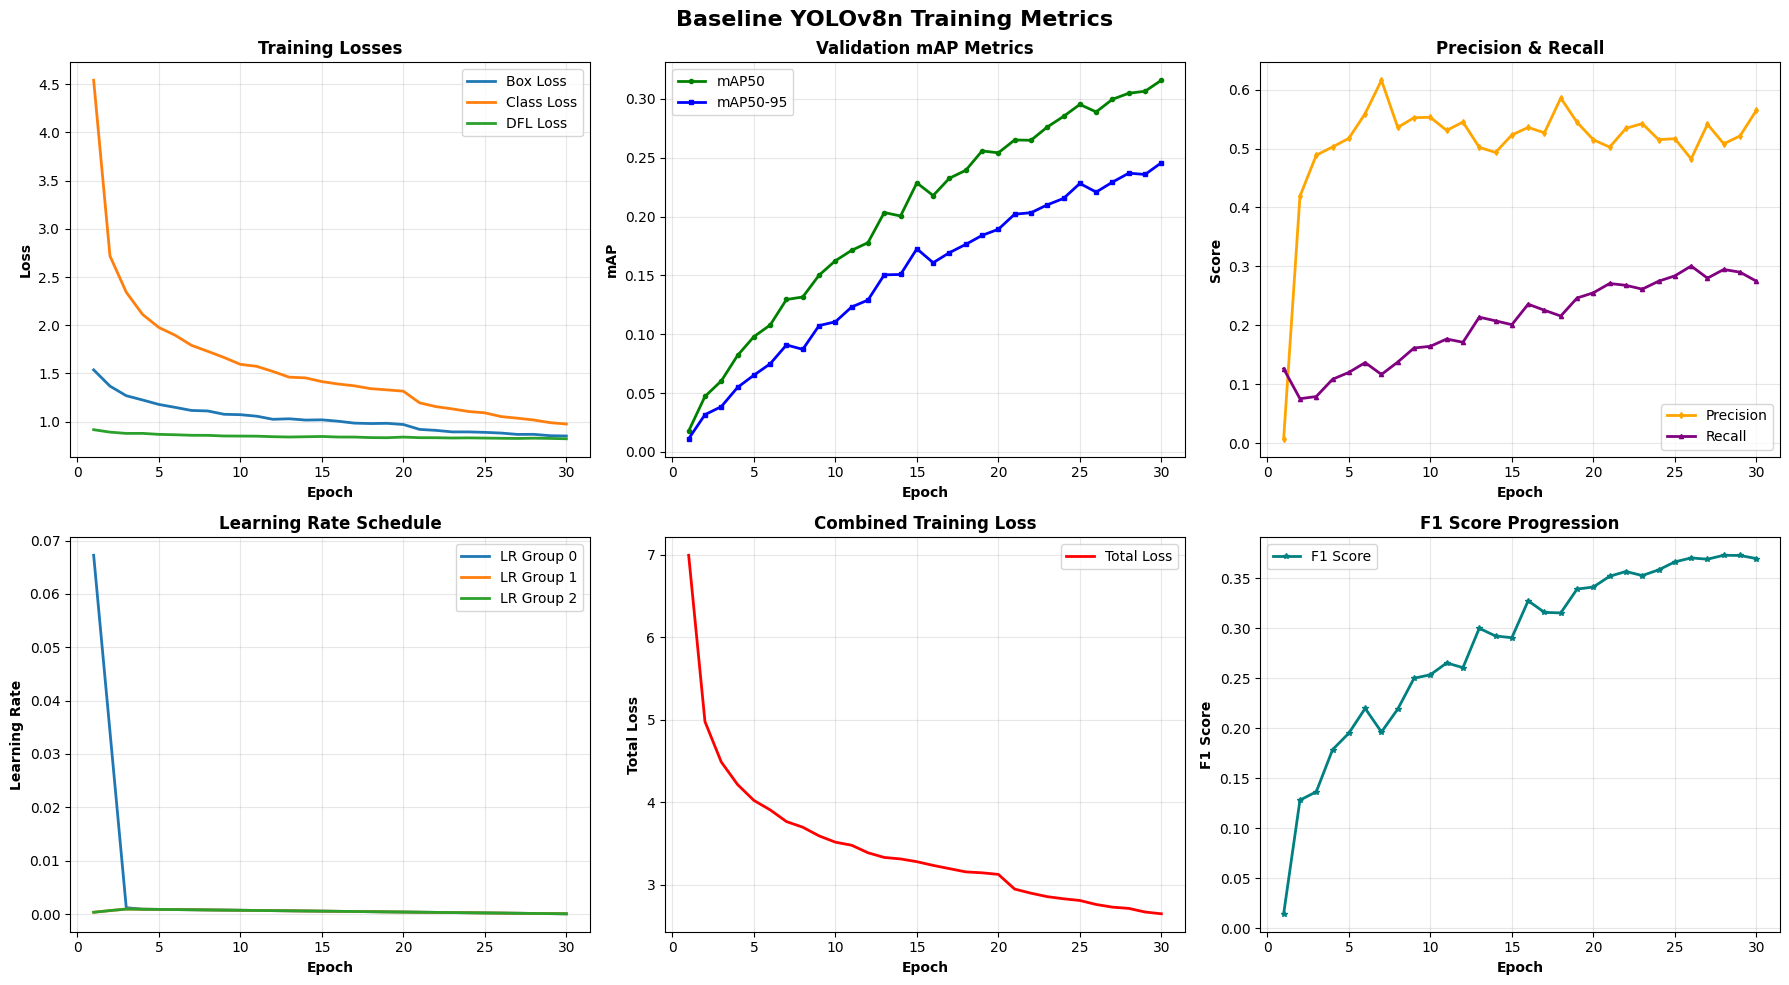


Baseline model training visualization complete!


In [12]:
# Load and visualize baseline training results
baseline_results_path = f"{WORK_ROOT}runs/detect/train/results.csv"
baseline_results_df = load_training_results(baseline_results_path)

print_training_metrics(baseline_results_df, "BASELINE MODEL")
baseline_total = plot_training_metrics(baseline_results_df, "Baseline YOLOv8n")

print("\nBaseline model training visualization complete!")

### 2.3 Baseline Model Validation Performance

Evaluate the trained baseline model on the validation set.

In [13]:
# Load best model and evaluate
model = YOLO(f"{WORK_ROOT}runs/detect/train/weights/best.pt")

# Validate on validation set
metrics = model.val(data=yaml_path, split="val")

print(f"\nmAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

# Per-class metrics
print("\nPer-class AP50:")
if hasattr(metrics.box, "ap_class_index"):
    for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50):
        class_name = id2class.get(int(idx), f"class_{idx}")
        print(f"  {class_name}: {ap:.4f}")

Ultralytics 8.3.241 🚀 Python-3.10.13 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
Model summary (fused): 72 layers, 3,371,327 parameters, 0 gradients, 9.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 300.6±17.6 MB/s, size: 1191.8 KB)
val: Scanning /home/avinna/Personal/TrafficSign/tt100k_yolo/labels/val.cache... 2119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2119/2119 1.3Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 133/133 3.3it/s 40.6s0.3s
                   all       2119       5438      0.608       0.38      0.435       0.34
                    i1          3          3      0.805      0.667      0.863      0.738
                   i10         14         15      0.635      0.667      0.674      0.493
                   i12          2          2          0          0    0.00511    0.00204
                   i13          4          4          1          0      0.266      

### 2.4 Baseline Performance Analysis: Rare vs Common Classes

Analyze how the baseline model performs on different class frequencies.

Common classes (top 20): 20
Rare classes (bottom 25%): 46

Average AP50 for common classes: 0.6962
Average AP50 for rare classes: 0.0508


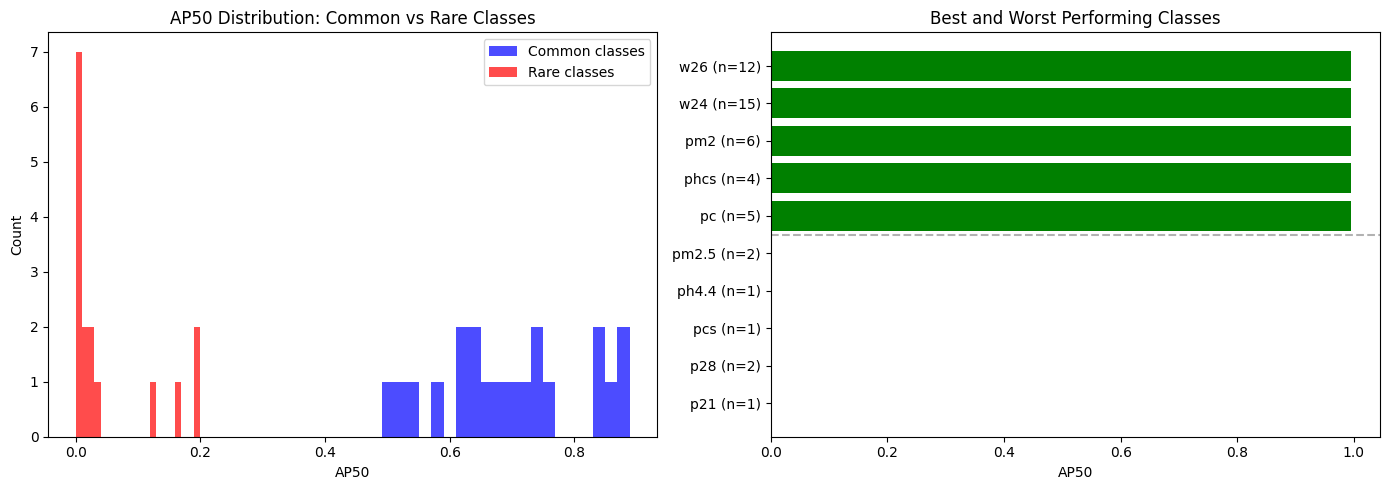


Worst performing classes:
  p21: AP50=0.0000, instances=1
  p28: AP50=0.0000, instances=2
  pcs: AP50=0.0000, instances=1
  ph4.4: AP50=0.0000, instances=1
  pm2.5: AP50=0.0000, instances=2

Best performing classes:
  pc: AP50=0.9950, instances=5
  phcs: AP50=0.9950, instances=4
  pm2: AP50=0.9950, instances=6
  w24: AP50=0.9950, instances=15
  w26: AP50=0.9950, instances=12


In [14]:
# Count instances per class from training labels
class_counts = Counter()
for label_file in os.listdir(LBL_TRAIN):
    with open(os.path.join(LBL_TRAIN, label_file)) as f:
        for line in f:
            cls_id = int(line.split()[0])
            class_counts[cls_id] += 1

# Categorize classes by frequency
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
common_classes = [c for c, cnt in sorted_counts[:20]]  # Top 20
rare_classes = [
    c
    for c, cnt in sorted_counts
    if cnt < np.percentile([c for _, c in sorted_counts], 25)
]

print(f"Common classes (top 20): {len(common_classes)}")
print(f"Rare classes (bottom 25%): {len(rare_classes)}")

# Compare performance
if hasattr(metrics.box, "ap_class_index") and hasattr(metrics.box, "ap50"):
    common_ap = [
        ap
        for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50)
        if int(idx) in common_classes
    ]
    rare_ap = [
        ap
        for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50)
        if int(idx) in rare_classes
    ]

    print(f"\nAverage AP50 for common classes: {np.mean(common_ap):.4f}")
    print(f"Average AP50 for rare classes: {np.mean(rare_ap):.4f}")

    # Visualize
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].hist(common_ap, bins=20, alpha=0.7, label="Common classes", color="blue")
    ax[0].hist(rare_ap, bins=20, alpha=0.7, label="Rare classes", color="red")
    ax[0].set_xlabel("AP50")
    ax[0].set_ylabel("Count")
    ax[0].set_title("AP50 Distribution: Common vs Rare Classes")
    ax[0].legend()

    # Top and bottom performers
    all_results = [
        (int(idx), ap, id2class.get(int(idx), f"cls_{idx}"), class_counts[int(idx)])
        for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50)
    ]
    all_results.sort(key=lambda x: x[1])

    worst_5 = all_results[:5]
    best_5 = all_results[-5:]

    ax[1].barh(
        range(10), [x[1] for x in worst_5 + best_5], color=["red"] * 5 + ["green"] * 5
    )
    ax[1].set_yticks(range(10))
    ax[1].set_yticklabels([f"{x[2]} (n={x[3]})" for x in worst_5 + best_5])
    ax[1].set_xlabel("AP50")
    ax[1].set_title("Best and Worst Performing Classes")
    ax[1].axhline(4.5, color="black", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nWorst performing classes:")
    for cls_id, ap, name, count in worst_5:
        print(f"  {name}: AP50={ap:.4f}, instances={count}")

    print("\nBest performing classes:")
    for cls_id, ap, name, count in best_5:
        print(f"  {name}: AP50={ap:.4f}, instances={count}")

---

## Part 3: Attention-Enhanced Model Implementation & Training

Implement CBAM (Channel + Spatial Attention) and Self-Attention mechanisms.

### 3.1 Attention Mechanism Modules

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from ultralytics import YOLO
import sys
import os

# ChannelAttention
class ChannelAttention(nn.Module):
    def __init__(self, ratio=16):
        super().__init__()
        self.ratio = ratio
        self.fc = None
        self.sigmoid = nn.Sigmoid()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
    
    def _init_fc(self, in_channels):
        hidden = max(1, in_channels // self.ratio)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, in_channels, 1, bias=False)
        )

    def forward(self, x):
        if self.fc is None:
            self._init_fc(x.shape[1])  # dynamically set channels
            self.fc = self.fc.to(x.device)
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = self.sigmoid(avg_out + max_out)
        return x * out



# Spatial Attention Module
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.sigmoid(self.conv(out))
        return x * out

# CBAM
class CBAM(nn.Module):
    def __init__(self, ratio=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(ratio)
        self.spatial_attention = SpatialAttention(kernel_size)
    
    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


class SelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.query = None
        self.key = None
        self.value = None
        self.gamma = nn.Parameter(torch.zeros(1))

    def _init_layers(self, in_channels):
        hidden = max(1, in_channels // 8)
        self.query = nn.Conv2d(in_channels, hidden, 1)
        self.key = nn.Conv2d(in_channels, hidden, 1)
        self.value = nn.Conv2d(in_channels, in_channels, 1)

    def forward(self, x):
        if self.query is None:
            self._init_layers(x.shape[1])
            device = x.device
            self.query = self.query.to(device)
            self.key = self.key.to(device)
            self.value = self.value.to(device)

        batch, C, H, W = x.size()
        query = self.query(x).view(batch, -1, H * W).permute(0, 2, 1)  # B x (H*W) x C'
        key = self.key(x).view(batch, -1, H * W)                        # B x C' x (H*W)
        value = self.value(x).view(batch, -1, H * W)                    # B x C x (H*W)

        attention = F.softmax(torch.bmm(query, key), dim=-1)            # B x (H*W) x (H*W)
        out = torch.bmm(value, attention.permute(0, 2, 1))              # B x C x (H*W)
        out = out.view(batch, C, H, W)
        return self.gamma * out + x                                     # Residual

print("Attention modules defined!")


Attention modules defined!


### 3.2 Create Custom YOLO Configuration

Define YOLO architecture with integrated attention mechanisms in backbone and neck.

In [16]:
# Create a custom YAML configuration for YOLO with attention
attention_config = f"""
# YOLOv8n with Attention Mechanisms
nc: {len(classes)}  
depth_multiple: 0.33
width_multiple: 0.25

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [32, True]]
  - [-1, 1, CBAM, []]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [64, True]]
  - [-1, 1, CBAM, []]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [128, True]]
  - [-1, 1, SelfAttention, []]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [256, True]]
  - [-1, 1, SPPF, [256, 5]]

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 3, C2f, [128]]
  - [-1, 1, CBAM, []]
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [64]]
  - [-1, 1, CBAM, []]
  - [-1, 1, Conv, [64, 3, 2]]
  - [[-1, 16], 1, Concat, [1]]
  - [-1, 3, C2f, [128]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]
  - [[20, 23, 26], 1, Detect, [{len(classes)}]]
"""

# Save the configuration
config_path = f"{OUT_ROOT}/yolov8n_attention.yaml"
with open(config_path, 'w') as f:
    f.write(attention_config.format(nc=len(classes)))

print(f"Attention-based YOLO config saved to: {config_path}")

Attention-based YOLO config saved to: tt100k_yolo/yolov8n_attention.yaml


### 3.3 Register Custom Modules

Register attention modules with Ultralytics framework for model building.

In [17]:
import ultralytics.nn.tasks as tasks

tasks.__dict__['CBAM'] = CBAM
tasks.__dict__['SelfAttention'] = SelfAttention
tasks.__dict__['ChannelAttention'] = ChannelAttention
tasks.__dict__['SpatialAttention'] = SpatialAttention

print("Custom attention modules registered!")

Custom attention modules registered!


### 3.4 Train Attention-Enhanced Model

Train the attention-enhanced model with identical hyperparameters as baseline for fair comparison.

In [18]:
# Initialize model with attention mechanisms
model_attention = YOLO(config_path)

# Train with same hyperparameters as baseline for fair comparison
results_attention = model_attention.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=64,
    # Same augmentation as baseline
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    save_period=5,
    device=0,
    workers=4,
    verbose=True,
    plots=True,
    name='train_attention'  # Different run name
)

print("Training with attention mechanisms completed!")

Ultralytics 8.3.252 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/tt100k_yolo/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/tt100k_yolo/yolov8n_attention.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_attention, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW,

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      9.18G      4.374       60.8      2.308         76        640: 100% ━━━━━━━━━━━━ 132/132 1.6s/it 3:32
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.3it/s 13.9s
                   all       2188       5662          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      9.22G      2.764      4.633      1.233         61        640: 100% ━━━━━━━━━━━━ 132/132 1.2s/it 2:40
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.0it/s 17.5s
                   all       2188       5662      0.004     0.0193     0.0036    0.00189

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      9.16G      2.616       4.25      1.178        251        640: 0% ──────────── 0/132  0.9s

...

      28/30      9.06G      1.261      1.896     0.8883         50        640: 100% ━━━━━━━━━━━━ 132/132 1.2s/it 2:42
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.1s/it 19.6s
                   all       2188       5662       0.56       0.12      0.108     0.0636

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/30      9.02G      1.321      1.866     0.8962        170        640: 0% ──────────── 0/132  0.9s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      29/30      9.07G       1.25      1.884     0.8874         46        640: 100% ━━━━━━━━━━━━ 132/132 1.2s/it 2:41
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.4s/it 25.4s
                   all       2188       5662      0.471      0.134      0.112     0.0662

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/30      9.02G      1.418      2.033     0.9475        154        640: 0% ──────────── 0/132  0.8s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30      9.06G      1.249      1.871     0.8828         57        640: 100% ━━━━━━━━━━━━ 132/132 1.2s/it 2:40
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.3s/it 22.9s
                   all       2188       5662      0.484       0.14      0.117     0.0712

30 epochs completed in 1.608 hours.
Optimizer stripped from /kaggle/working/runs/detect/train_attention/weights/last.pt, 2.0MB
Optimizer stripped from /kaggle/working/runs/detect/train_attention/weights/best.pt, 2.0MB

Validating /kaggle/working/runs/detect/train_attention/weights/best.pt...
Ultralytics 8.3.252 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv8n_attention summary (fused): 107 layers, 857,976 parameters, 0 gradients, 3.9 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.9s/it 33.7s
                   all       2188       5662      0.484  

### 3.5 Attention Model Training Metrics Visualization

Analyze attention model training progression.

ATTENTION MODEL TRAINING METRICS
Total epochs: 30
Final metrics:
  Box Loss: 1.2488
  Class Loss: 1.8708
  DFL Loss: 0.8828
  Val mAP50: 0.1166
  Val mAP50-95: 0.0712


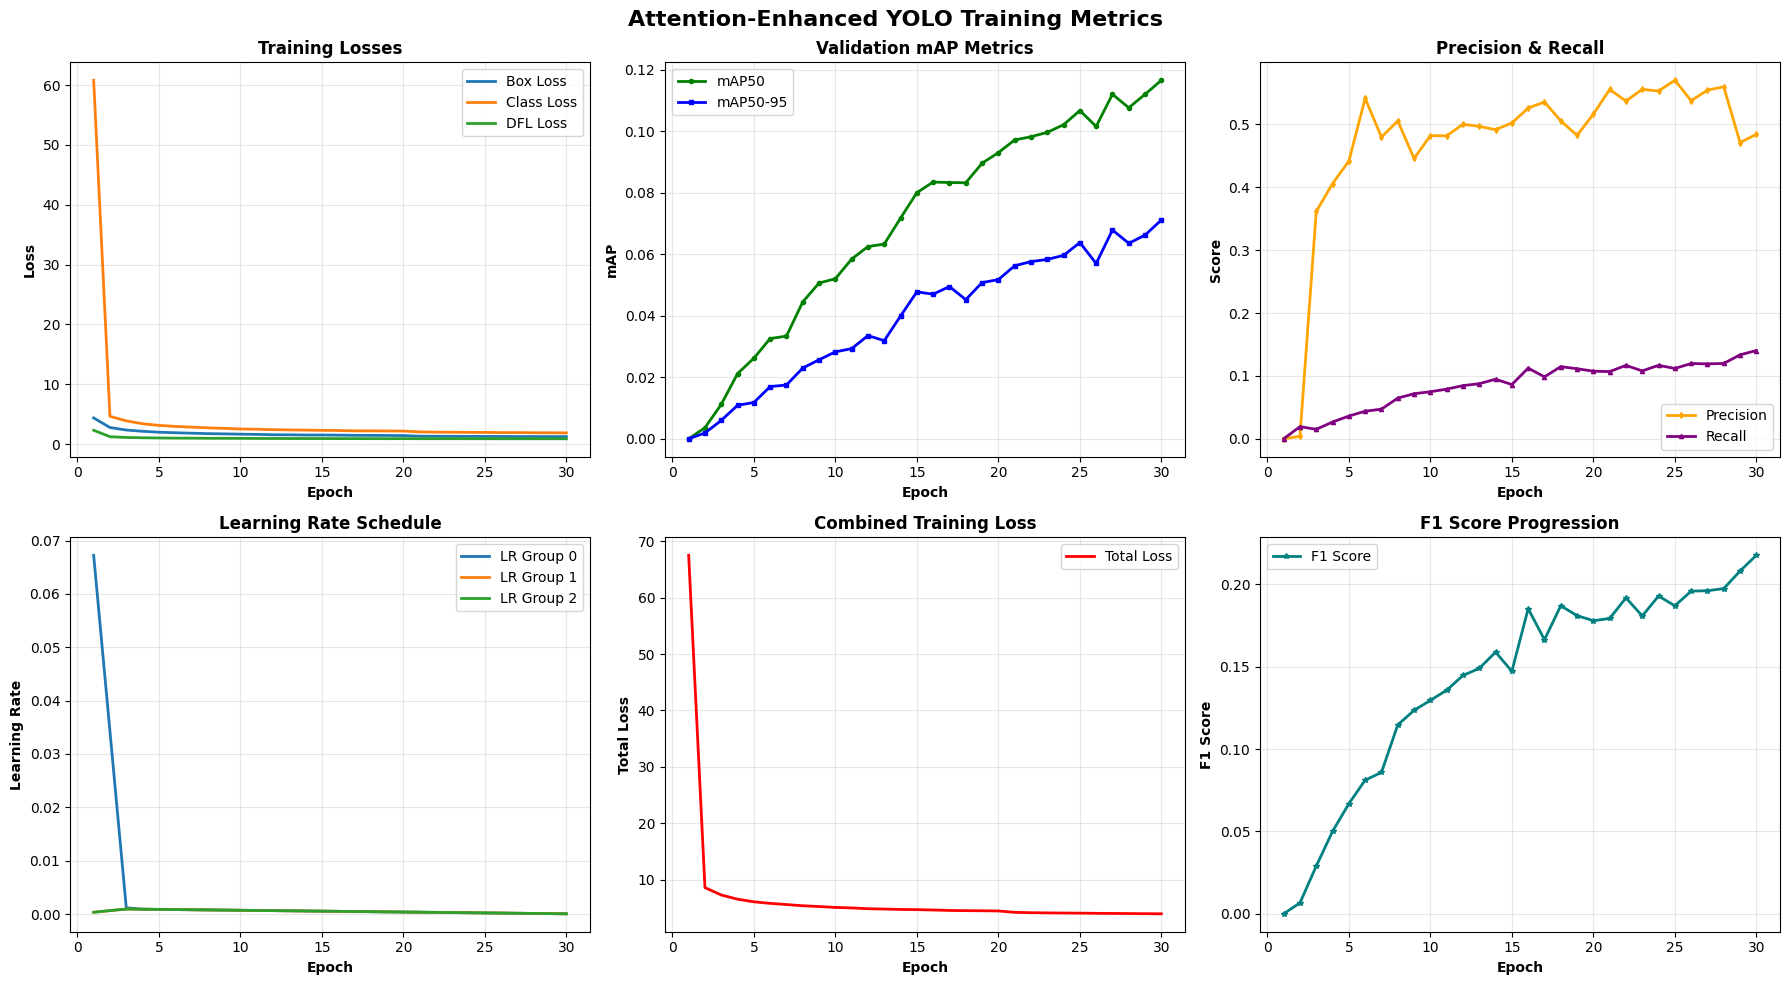


Attention model training visualization complete!


In [18]:
# Load and visualize attention training results
attention_results_path = f"{WORK_ROOT}runs/detect/train_attention/results.csv"
attention_results_df = load_training_results(attention_results_path)

print_training_metrics(attention_results_df, "ATTENTION MODEL")
attention_total = plot_training_metrics(attention_results_df, "Attention-Enhanced YOLO")

print("\nAttention model training visualization complete!")

### 3.6 Training Curves Comparison: Baseline vs Attention

Compare training progression between both models.

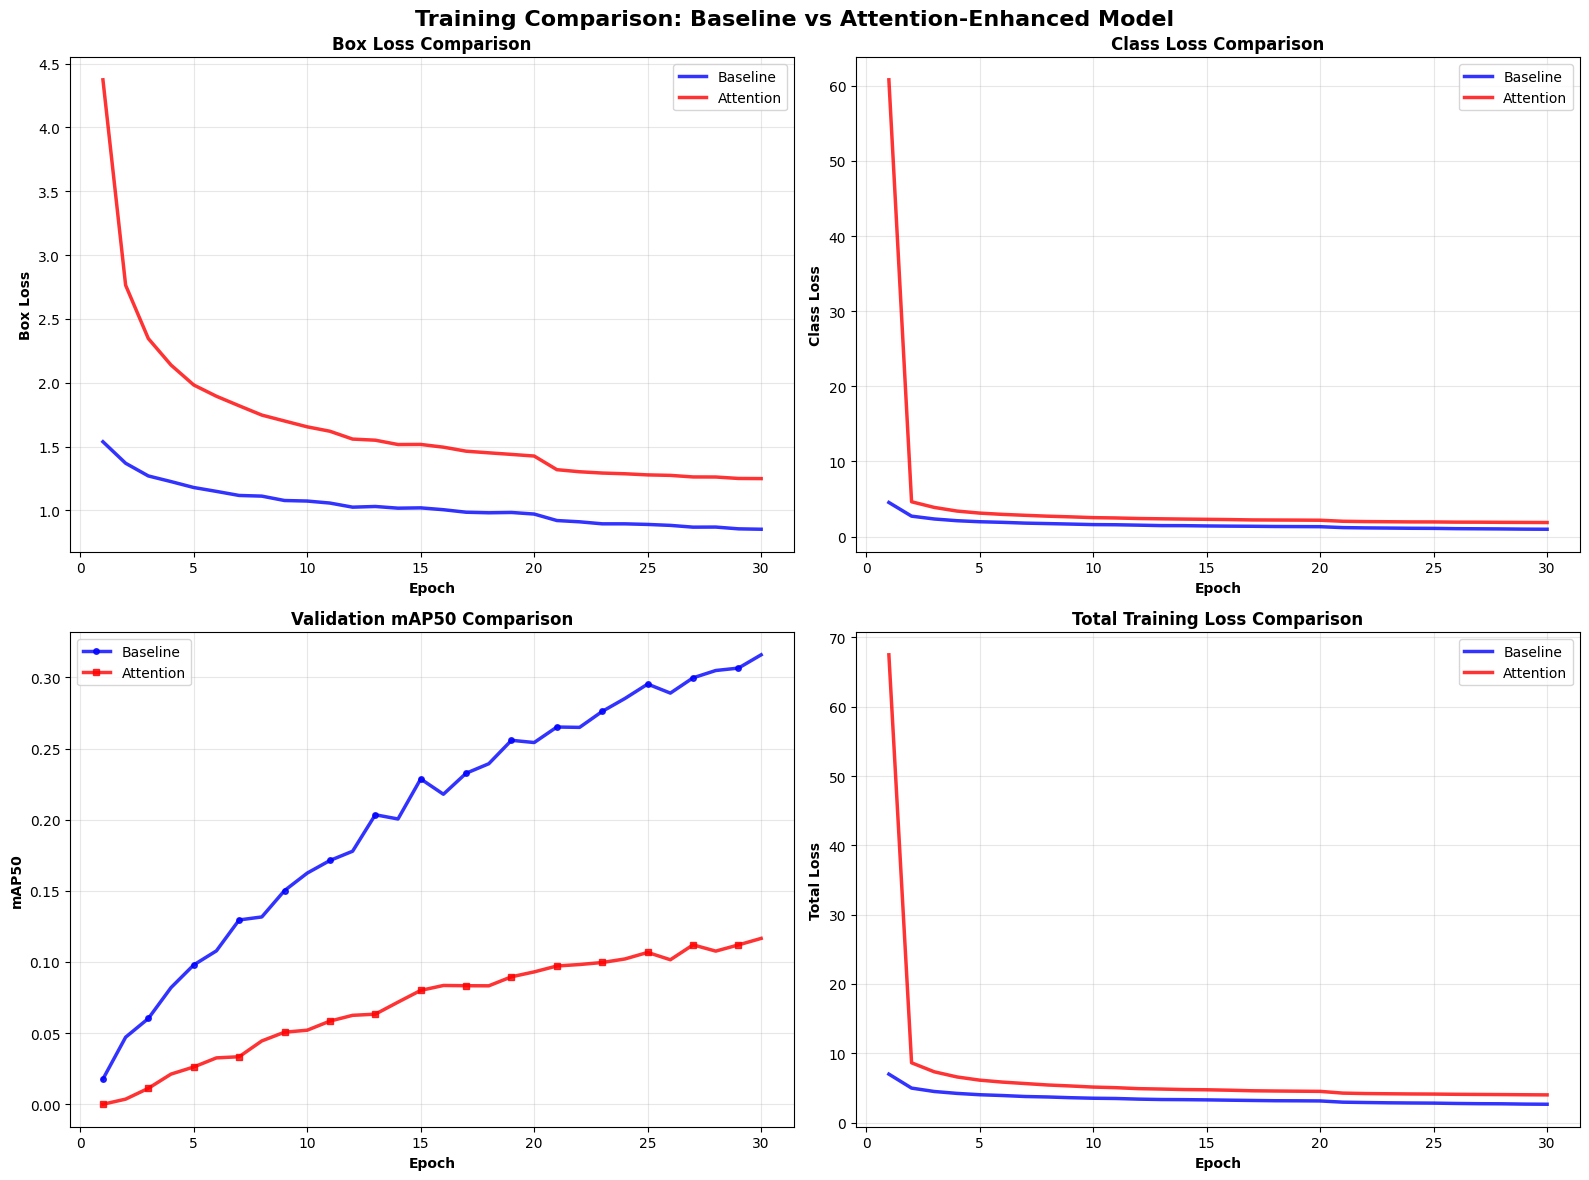

TRAINING CONVERGENCE SUMMARY

Final mAP50:
  Baseline:  0.3159
  Attention: 0.1166
  Difference: -0.1993 (-63.10%)

Final Total Loss:
  Baseline:  2.6505
  Attention: 4.0024
  Difference: 1.3518 (+51.00%)

Best Performance Epochs:
  Baseline:  Epoch 29 (mAP50: 0.3159)
  Attention: Epoch 29 (mAP50: 0.1166)


In [19]:
# Compare training curves between both models
compare_training_curves(baseline_results_df, attention_results_df)

print("TRAINING CONVERGENCE SUMMARY")

baseline_final_map = baseline_results_df['metrics/mAP50(B)'].iloc[-1]
attention_final_map = attention_results_df['metrics/mAP50(B)'].iloc[-1]

baseline_final_loss = baseline_total.iloc[-1]
attention_final_loss = attention_total.iloc[-1]

print(f"\nFinal mAP50:")
print(f"  Baseline:  {baseline_final_map:.4f}")
print(f"  Attention: {attention_final_map:.4f}")
print(f"  Difference: {(attention_final_map - baseline_final_map):.4f} ({((attention_final_map - baseline_final_map) / baseline_final_map * 100):+.2f}%)")

print(f"\nFinal Total Loss:")
print(f"  Baseline:  {baseline_final_loss:.4f}")
print(f"  Attention: {attention_final_loss:.4f}")
print(f"  Difference: {(attention_final_loss - baseline_final_loss):.4f} ({((attention_final_loss - baseline_final_loss) / baseline_final_loss * 100):+.2f}%)")

# Find best epochs
baseline_best_epoch = baseline_results_df['metrics/mAP50(B)'].idxmax()
attention_best_epoch = attention_results_df['metrics/mAP50(B)'].idxmax()

print(f"\nBest Performance Epochs:")
print(f"  Baseline:  Epoch {baseline_best_epoch} (mAP50: {baseline_results_df['metrics/mAP50(B)'].iloc[baseline_best_epoch]:.4f})")
print(f"  Attention: Epoch {attention_best_epoch} (mAP50: {attention_results_df['metrics/mAP50(B)'].iloc[attention_best_epoch]:.4f})")


### 3.7 Training Completion Summary

Both models trained successfully - ready for comprehensive evaluation.

In [20]:
print("\nTraining Summary:\n")

print("1. BASELINE YOLOv8n MODEL")
print(f"   Location: {WORK_ROOT}runs/detect/train/weights/best.pt")
print(f"   Epochs completed: {len(baseline_results_df)}")
print(f"   Final training loss: {baseline_total.iloc[-1]:.4f}")
print(f"   Final validation mAP50: {baseline_results_df['metrics/mAP50(B)'].iloc[-1]:.4f}")
print(f"   Final validation mAP50-95: {baseline_results_df['metrics/mAP50-95(B)'].iloc[-1]:.4f}")
print(f"   Best mAP50: {baseline_results_df['metrics/mAP50(B)'].max():.4f} (Epoch {baseline_results_df['metrics/mAP50(B)'].idxmax()})")

print("\n2. ATTENTION-ENHANCED YOLO MODEL")
print(f"   Location: {WORK_ROOT}runs/detect/train_attention/weights/best.pt")
print(f"   Epochs completed: {len(attention_results_df)}")
print(f"   Final training loss: {attention_total.iloc[-1]:.4f}")
print(f"   Final validation mAP50: {attention_results_df['metrics/mAP50(B)'].iloc[-1]:.4f}")
print(f"   Final validation mAP50-95: {attention_results_df['metrics/mAP50-95(B)'].iloc[-1]:.4f}")
print(f"   Best mAP50: {attention_results_df['metrics/mAP50(B)'].max():.4f} (Epoch {attention_results_df['metrics/mAP50(B)'].idxmax()})")


Training Summary:

1. BASELINE YOLOv8n MODEL
   Location: runs/detect/train/weights/best.pt
   Epochs completed: 30
   Final training loss: 2.6505
   Final validation mAP50: 0.3159
   Final validation mAP50-95: 0.2458
   Best mAP50: 0.3159 (Epoch 29)

2. ATTENTION-ENHANCED YOLO MODEL
   Location: runs/detect/train_attention/weights/best.pt
   Epochs completed: 30
   Final training loss: 4.0024
   Final validation mAP50: 0.1166
   Final validation mAP50-95: 0.0712
   Best mAP50: 0.1166 (Epoch 29)


---

## Part 4: Comprehensive Model Comparison & Evaluation

Evaluate both models on validation set and compare key metrics.

### 4.1 Validation Performance Metrics

In [21]:
# Load both models
model_baseline = YOLO(f"{WORK_ROOT}runs/detect/train/weights/best.pt")
model_attention = YOLO(f"{WORK_ROOT}runs/detect/train_attention/weights/best.pt")

print("MODEL COMPARISON: Baseline YOLOv8n vs Attention-Enhanced YOLOv8n")

# Evaluate both models on validation set
print("\nEvaluating Baseline Model...")
metrics_baseline = model_baseline.val(data=yaml_path, split="val")

print("\nEvaluating Attention-Enhanced Model...")
metrics_attention = model_attention.val(data=yaml_path, split="val")

# Create comparison dictionary
comparison = {
    'Metric': ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1-Score'],
    'Baseline': [
        metrics_baseline.box.map50,
        metrics_baseline.box.map,
        metrics_baseline.box.mp,
        metrics_baseline.box.mr,
        2 * (metrics_baseline.box.mp * metrics_baseline.box.mr) / (metrics_baseline.box.mp + metrics_baseline.box.mr + 1e-6)
    ],
    'Attention': [
        metrics_attention.box.map50,
        metrics_attention.box.map,
        metrics_attention.box.mp,
        metrics_attention.box.mr,
        2 * (metrics_attention.box.mp * metrics_attention.box.mr) / (metrics_attention.box.mp + metrics_attention.box.mr + 1e-6)
    ]
}

# Calculate improvements
comparison['Improvement (%)'] = [
    ((att - base) / base * 100) if base > 0 else 0
    for base, att in zip(comparison['Baseline'], comparison['Attention'])
]

# Display comparison table
print("OVERALL METRICS COMPARISON")
for i, metric in enumerate(comparison['Metric']):
    base_val = comparison['Baseline'][i]
    att_val = comparison['Attention'][i]
    imp_val = comparison['Improvement (%)'][i]
    
    improvement_sign = "↑" if imp_val > 0 else "↓" if imp_val < 0 else "→"
    print(f"{metric:12s}: Baseline={base_val:.4f} | Attention={att_val:.4f} | {improvement_sign} {imp_val:+.2f}%")

MODEL COMPARISON: Baseline YOLOv8n vs Attention-Enhanced YOLOv8n

Evaluating Baseline Model...
Ultralytics 8.3.241 🚀 Python-3.10.13 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
Model summary (fused): 72 layers, 3,371,327 parameters, 0 gradients, 9.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1633.2±1634.5 MB/s, size: 1180.8 KB)
val: Scanning /home/avinna/Personal/TrafficSign/tt100k_yolo/labels/val.cache... 2119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2119/2119 1.9Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 133/133 3.3it/s 40.4s0.3s
                   all       2119       5438      0.608       0.38      0.435       0.34
                    i1          3          3      0.805      0.667      0.863      0.738
                   i10         14         15      0.635      0.667      0.674      0.493
                   i12          2          2          0          0    0.00

### 4.2 Per-Class Performance Analysis

Detailed analysis of how attention mechanisms affect each class.

In [ ]:
# Per-class comparison
if hasattr(metrics_baseline.box, "ap_class_index") and hasattr(
    metrics_attention.box, "ap_class_index"
):
    # Create per-class comparison
    class_improvements = []

    baseline_aps = dict(
        zip(
            [int(idx) for idx in metrics_baseline.box.ap_class_index],
            metrics_baseline.box.ap50,
        )
    )
    attention_aps = dict(
        zip(
            [int(idx) for idx in metrics_attention.box.ap_class_index],
            metrics_attention.box.ap50,
        )
    )

    for cls_id in baseline_aps.keys():
        if cls_id in attention_aps:
            base_ap = baseline_aps[cls_id]
            att_ap = attention_aps[cls_id]
            improvement = ((att_ap - base_ap) / base_ap * 100) if base_ap > 0 else 0
            class_name = id2class.get(cls_id, f"class_{cls_id}")
            class_count = class_counts.get(cls_id, 0)

            class_improvements.append(
                {
                    "class_id": cls_id,
                    "class_name": class_name,
                    "count": class_count,
                    "baseline_ap": base_ap,
                    "attention_ap": att_ap,
                    "improvement": improvement,
                }
            )

    # Sort by improvement
    class_improvements.sort(key=lambda x: x["improvement"], reverse=True)

    print("TOP 10 MOST IMPROVED CLASSES")
    print(
        f"{'Class Name':<25} {'Instances':<12} {'Baseline AP':<15} {'Attention AP':<15} {'Improvement':<15}"
    )

    for item in class_improvements[:10]:
        print(
            f"{item['class_name']:<25} {item['count']:<12} {item['baseline_ap']:<15.4f} {item['attention_ap']:<15.4f} {item['improvement']:+.2f}%"
        )

    print("TOP 10 MOST DEGRADED CLASSES")
    print(
        f"{'Class Name':<25} {'Instances':<12} {'Baseline AP':<15} {'Attention AP':<15} {'Improvement':<15}"
    )

    for item in class_improvements[-10:]:
        print(
            f"{item['class_name']:<25} {item['count']:<12} {item['baseline_ap']:<15.4f} {item['attention_ap']:<15.4f} {item['improvement']:+.2f}%"
        )

    # Statistics
    improvements_list = [x["improvement"] for x in class_improvements]
    positive_improvements = [x for x in improvements_list if x > 0]
    negative_improvements = [x for x in improvements_list if x < 0]

    print("IMPROVEMENT STATISTICS")
    print(
        f"Classes improved: {len(positive_improvements)} ({len(positive_improvements)/len(improvements_list)*100:.1f}%)"
    )
    print(
        f"Classes degraded: {len(negative_improvements)} ({len(negative_improvements)/len(improvements_list)*100:.1f}%)"
    )
    print(f"Average improvement: {np.mean(improvements_list):.2f}%")
    print(f"Median improvement: {np.median(improvements_list):.2f}%")
    print(f"Max improvement: {np.max(improvements_list):.2f}%")
    print(f"Max degradation: {np.min(improvements_list):.2f}%")

TOP 10 MOST IMPROVED CLASSES
Class Name                Instances    Baseline AP     Attention AP    Improvement    
w50                       2            0.0195          0.9950          +5000.00%
w66                       3            0.0622          0.9950          +1500.00%
ph3                       26           0.0060          0.0905          +1418.18%
pt                        6            0.0064          0.0829          +1200.00%
pm5                       14           0.0681          0.4955          +627.73%
pm46                      5            0.0221          0.1421          +542.86%
w34                       14           0.0576          0.1715          +197.89%
p8                        11           0.0737          0.1043          +41.46%
p21                       1            0.0000          0.0000          +0.00%
p28                       2            0.0000          0.0000          +0.00%
TOP 10 MOST DEGRADED CLASSES
Class Name                Instances    Baseline AP     A

### 4.3 Visual Performance Comparison

Comprehensive visualizations comparing both models across multiple dimensions.

/tmp/ipykernel_2275/3227495963.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,


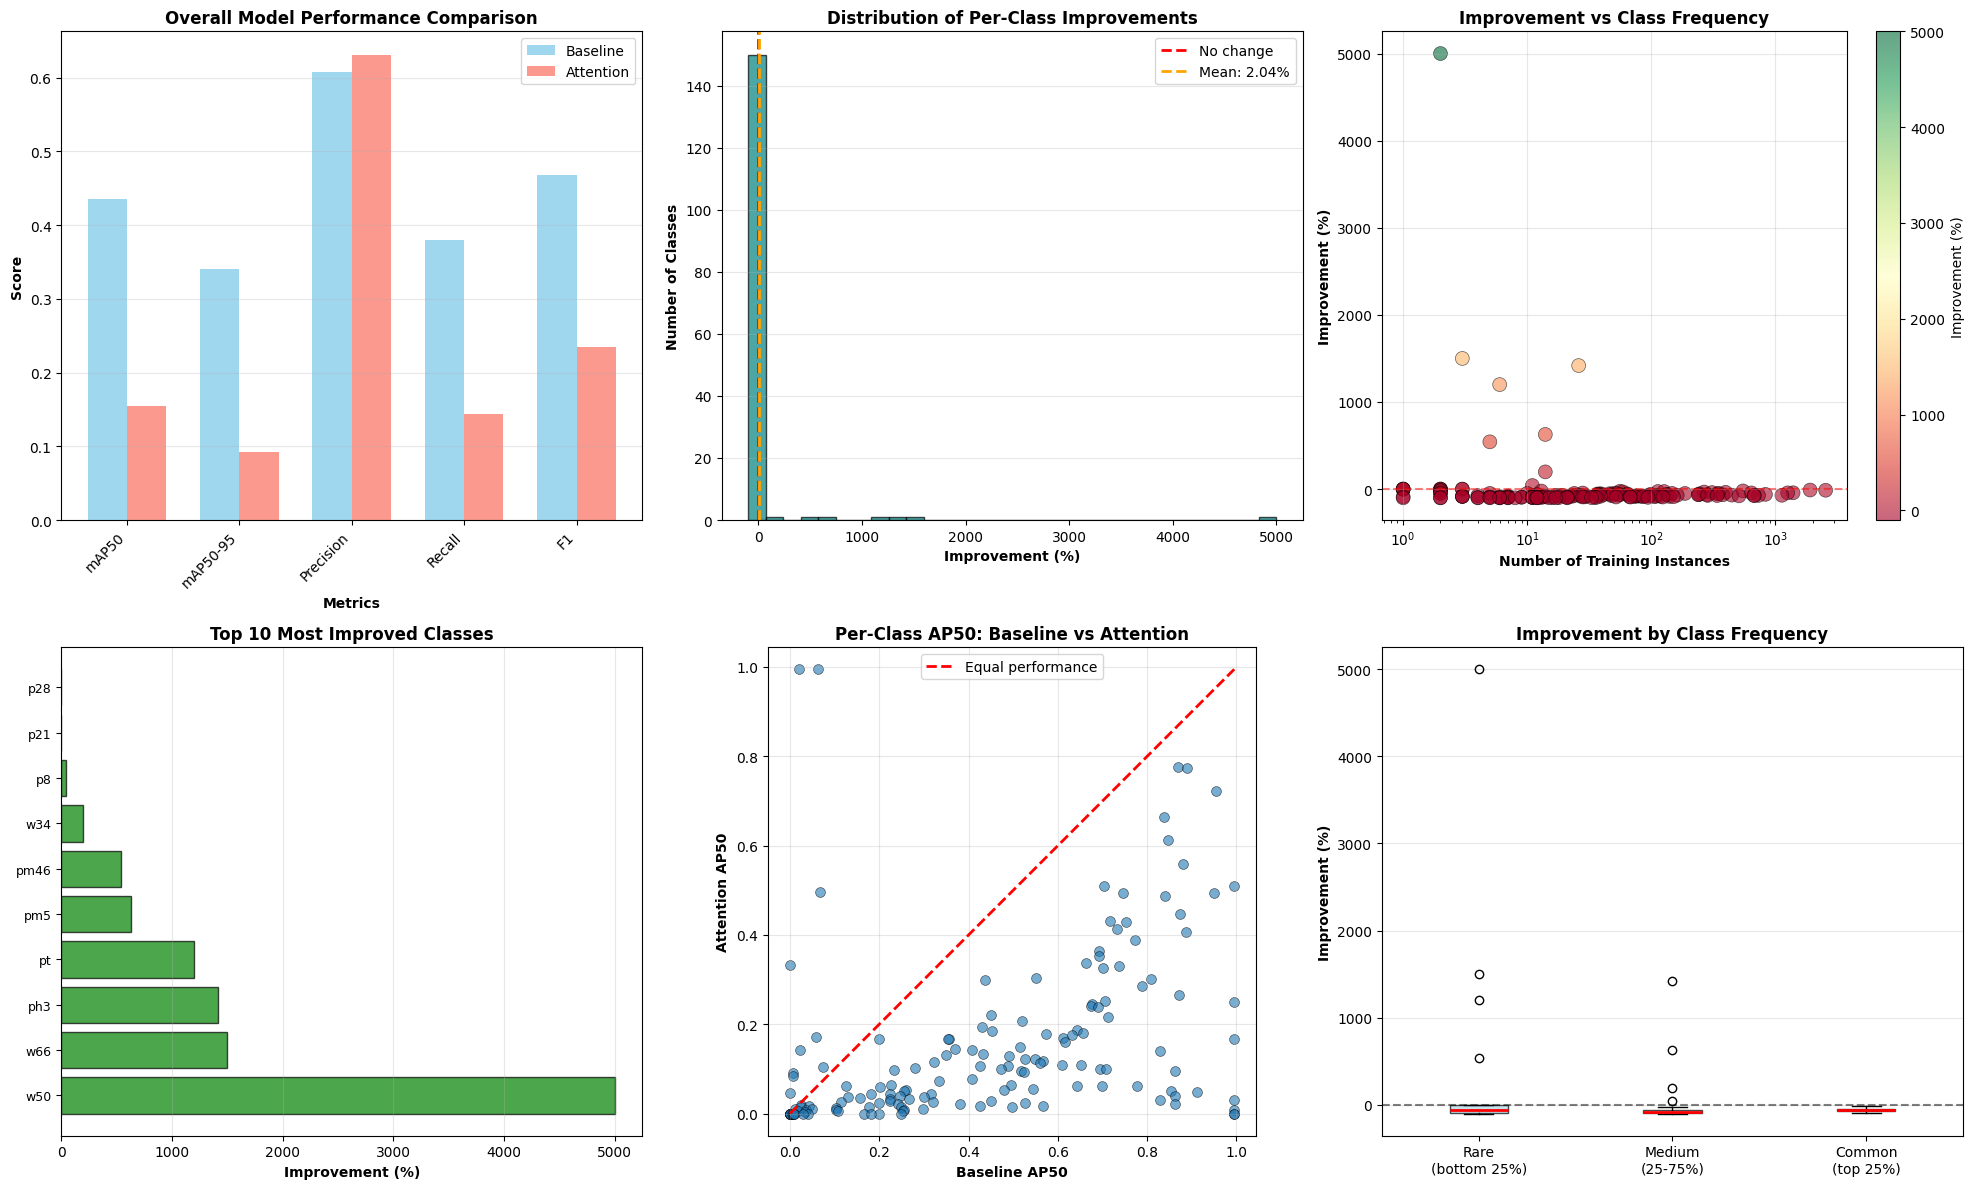


Visualization complete!


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Overall Metrics Comparison
ax = axes[0, 0]
metrics_names = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35

baseline_values = [
    metrics_baseline.box.map50,
    metrics_baseline.box.map,
    metrics_baseline.box.mp,
    metrics_baseline.box.mr,
    2 * (metrics_baseline.box.mp * metrics_baseline.box.mr) / (metrics_baseline.box.mp + metrics_baseline.box.mr + 1e-6)
]

attention_values = [
    metrics_attention.box.map50,
    metrics_attention.box.map,
    metrics_attention.box.mp,
    metrics_attention.box.mr,
    2 * (metrics_attention.box.mp * metrics_attention.box.mr) / (metrics_attention.box.mp + metrics_attention.box.mr + 1e-6)
]

ax.bar(x_pos - width/2, baseline_values, width, label='Baseline', color='skyblue', alpha=0.8)
ax.bar(x_pos + width/2, attention_values, width, label='Attention', color='salmon', alpha=0.8)
ax.set_xlabel('Metrics', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Overall Model Performance Comparison', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Improvement Distribution
ax = axes[0, 1]
if class_improvements:
    improvements = [x['improvement'] for x in class_improvements]
    ax.hist(improvements, bins=30, color='teal', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
    ax.axvline(np.mean(improvements), color='orange', linestyle='--', linewidth=2, label=f'Mean: {np.mean(improvements):.2f}%')
    ax.set_xlabel('Improvement (%)', fontweight='bold')
    ax.set_ylabel('Number of Classes', fontweight='bold')
    ax.set_title('Distribution of Per-Class Improvements', fontweight='bold', fontsize=12)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# 3. Improvement vs Class Frequency
ax = axes[0, 2]
if class_improvements:
    counts = [x['count'] for x in class_improvements]
    improvements = [x['improvement'] for x in class_improvements]
    scatter = ax.scatter(counts, improvements, c=improvements, cmap='RdYlGn', 
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Number of Training Instances', fontweight='bold')
    ax.set_ylabel('Improvement (%)', fontweight='bold')
    ax.set_title('Improvement vs Class Frequency', fontweight='bold', fontsize=12)
    ax.set_xscale('log')
    plt.colorbar(scatter, ax=ax, label='Improvement (%)')
    ax.grid(True, alpha=0.3)

# 4. Top Improved Classes
ax = axes[1, 0]
if class_improvements:
    top_improved = class_improvements[:10]
    names = [x['class_name'][:20] for x in top_improved]
    imps = [x['improvement'] for x in top_improved]
    colors = ['green' if x > 0 else 'red' for x in imps]
    
    y_pos = np.arange(len(names))
    ax.barh(y_pos, imps, color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Improvement (%)', fontweight='bold')
    ax.set_title('Top 10 Most Improved Classes', fontweight='bold', fontsize=12)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(axis='x', alpha=0.3)

# 5. AP Comparison Scatter
ax = axes[1, 1]
if class_improvements:
    baseline_aps_list = [x['baseline_ap'] for x in class_improvements]
    attention_aps_list = [x['attention_ap'] for x in class_improvements]
    
    ax.scatter(baseline_aps_list, attention_aps_list, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    
    # Diagonal line (y=x)
    max_val = max(max(baseline_aps_list), max(attention_aps_list))
    ax.plot([0, max_val], [0, max_val], 'r--', label='Equal performance', linewidth=2)
    
    ax.set_xlabel('Baseline AP50', fontweight='bold')
    ax.set_ylabel('Attention AP50', fontweight='bold')
    ax.set_title('Per-Class AP50: Baseline vs Attention', fontweight='bold', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

# 6. Rare vs Common Class Performance
ax = axes[1, 2]
if class_improvements:
    # Categorize by frequency
    rare_improvements = [x['improvement'] for x in class_improvements if x['count'] < np.percentile([y['count'] for y in class_improvements], 25)]
    common_improvements = [x['improvement'] for x in class_improvements if x['count'] >= np.percentile([y['count'] for y in class_improvements], 75)]
    medium_improvements = [x['improvement'] for x in class_improvements if np.percentile([y['count'] for y in class_improvements], 25) <= x['count'] < np.percentile([y['count'] for y in class_improvements], 75)]
    
    data_to_plot = [rare_improvements, medium_improvements, common_improvements]
    labels = ['Rare\n(bottom 25%)', 'Medium\n(25-75%)', 'Common\n(top 25%)']
    
    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_ylabel('Improvement (%)', fontweight='bold')
    ax.set_title('Improvement by Class Frequency', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

### 4.4 Side-by-Side Prediction Comparison

Compare actual detection outputs from both models on same images.

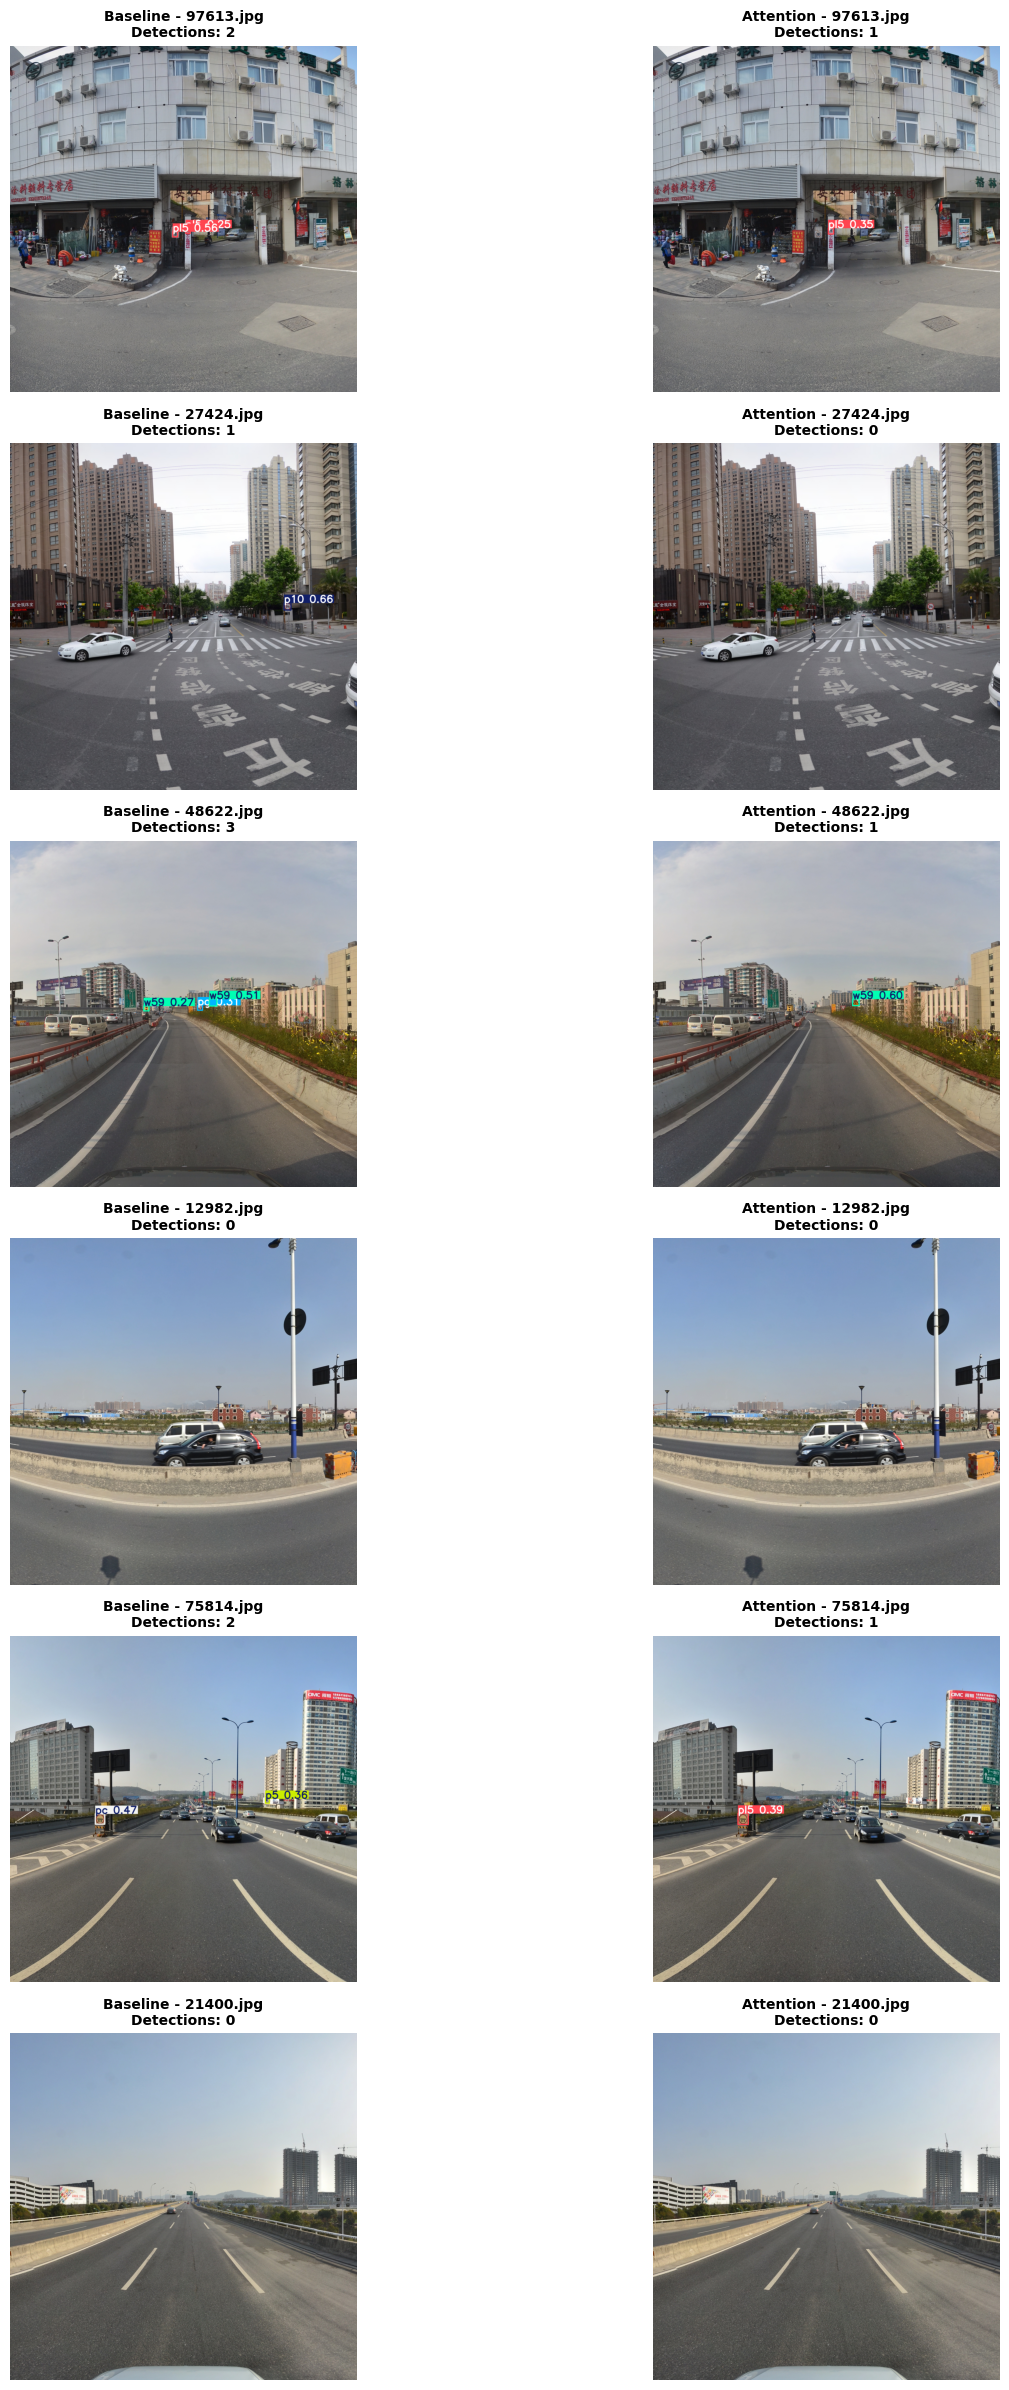

 Prediction comparison complete!


In [24]:
# Compare predictions on validation images
val_images = [os.path.join(IMG_VAL, f) for f in os.listdir(IMG_VAL)[:6]]
plot_prediction_comparison(model_baseline, model_attention, val_images, 'Baseline', 'Attention', max_images=6)

print(" Prediction comparison complete!")

### 4.5 Computational Efficiency Analysis

Compare model size and inference speed.

MODEL SIZE COMPARISON
Baseline model size: 6.66 MB
Attention model size: 1.87 MB
Size increase: -4.79 MB (-71.93%)
INFERENCE SPEED COMPARISON (50 images)
Baseline inference time: 2.886 seconds (57.72 ms/image)
Attention inference time: 3.098 seconds (61.97 ms/image)
Speed difference: +7.36%
Baseline FPS: 17.33
Attention FPS: 16.14


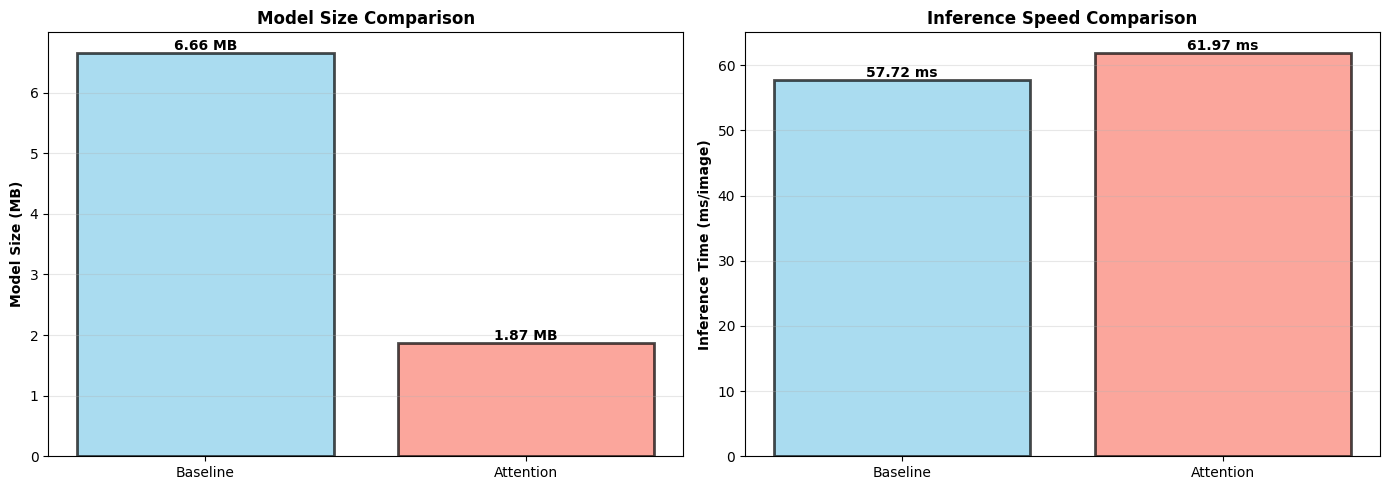

In [25]:
# Model size comparison
baseline_size = os.path.getsize(f"{WORK_ROOT}runs/detect/train/weights/best.pt") / (1024 * 1024)  # MB
attention_size = os.path.getsize(f"{WORK_ROOT}runs/detect/train_attention/weights/best.pt") / (1024 * 1024)  # MB

print("MODEL SIZE COMPARISON")
print(f"Baseline model size: {baseline_size:.2f} MB")
print(f"Attention model size: {attention_size:.2f} MB")
print(f"Size increase: {(attention_size - baseline_size):.2f} MB ({((attention_size/baseline_size - 1) * 100):+.2f}%)")

# Inference speed comparison
test_images = [os.path.join(IMG_VAL, f) for f in os.listdir(IMG_VAL)[:50]]

print("INFERENCE SPEED COMPARISON (50 images)")

# Baseline inference time
start_time = time.time()
for img_path in test_images:
    _ = model_baseline.predict(img_path, conf=0.25, verbose=False)
baseline_time = time.time() - start_time

# Attention inference time
start_time = time.time()
for img_path in test_images:
    _ = model_attention.predict(img_path, conf=0.25, verbose=False)
attention_time = time.time() - start_time

print(f"Baseline inference time: {baseline_time:.3f} seconds ({baseline_time/50*1000:.2f} ms/image)")
print(f"Attention inference time: {attention_time:.3f} seconds ({attention_time/50*1000:.2f} ms/image)")
print(f"Speed difference: {((attention_time/baseline_time - 1) * 100):+.2f}%")
print(f"Baseline FPS: {50/baseline_time:.2f}")
print(f"Attention FPS: {50/attention_time:.2f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Size comparison
ax = axes[0]
models = ['Baseline', 'Attention']
sizes = [baseline_size, attention_size]
colors = ['skyblue', 'salmon']
bars = ax.bar(models, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Model Size (MB)', fontweight='bold')
ax.set_title('Model Size Comparison', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{size:.2f} MB',
            ha='center', va='bottom', fontweight='bold')

# Speed comparison
ax = axes[1]
times = [baseline_time/50*1000, attention_time/50*1000]
bars = ax.bar(models, times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Inference Time (ms/image)', fontweight='bold')
ax.set_title('Inference Speed Comparison', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{time_val:.2f} ms',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---

## Part 5: Real-World Testing & Final Recommendations

Test both models on real-world traffic sign images (if available).

### 5.1 Real-World Image Testing

In [26]:
if os.path.exists("real_test"):
    print("REAL-WORLD TEST SET COMPARISON")

    # Baseline predictions
    print("\n Running baseline model on real-world images...")
    results_base_real = model_baseline.predict(
        source="real_test",
        conf=0.25,
        save=True,
        save_txt=True,
        save_conf=True,
        project=f"{WORK_ROOT}runs/detect",
        name="predict_baseline",
        verbose=False,
    )

    # Attention predictions
    print("Running attention model on real-world images...")
    results_att_real = model_attention.predict(
        source="real_test",
        conf=0.25,
        save=True,
        save_txt=True,
        save_conf=True,
        project=f"{WORK_ROOT}runs/detect",
        name="predict_attention",
        verbose=False,
    )

    # Analyze results
    baseline_confidences = []
    baseline_detections = 0
    baseline_classes = []

    attention_confidences = []
    attention_detections = 0
    attention_classes = []

    for r_base, r_att in zip(results_base_real, results_att_real):
        if len(r_base.boxes) > 0:
            baseline_confidences.extend([float(conf) for conf in r_base.boxes.conf])
            baseline_detections += len(r_base.boxes)
            baseline_classes.extend([int(cls) for cls in r_base.boxes.cls])

        if len(r_att.boxes) > 0:
            attention_confidences.extend([float(conf) for conf in r_att.boxes.conf])
            attention_detections += len(r_att.boxes)
            attention_classes.extend([int(cls) for cls in r_att.boxes.cls])

    # Print statistics
    print("REAL-WORLD DETECTION STATISTICS")
    print(f"{'Metric':<30} {'Baseline':<20} {'Attention':<20} {'Difference':<20}")
    print(
        f"{'Total detections':<30} {baseline_detections:<20} {attention_detections:<20} {attention_detections - baseline_detections:<20}"
    )

    if baseline_confidences and attention_confidences:
        print(
            f"{'Average confidence':<30} {np.mean(baseline_confidences):<20.3f} {np.mean(attention_confidences):<20.3f} {np.mean(attention_confidences) - np.mean(baseline_confidences):<20.3f}"
        )
        print(
            f"{'Median confidence':<30} {np.median(baseline_confidences):<20.3f} {np.median(attention_confidences):<20.3f} {np.median(attention_confidences) - np.median(baseline_confidences):<20.3f}"
        )
        print(
            f"{'Min confidence':<30} {np.min(baseline_confidences):<20.3f} {np.min(attention_confidences):<20.3f} {np.min(attention_confidences) - np.min(baseline_confidences):<20.3f}"
        )
        print(
            f"{'Max confidence':<30} {np.max(baseline_confidences):<20.3f} {np.max(attention_confidences):<20.3f} {np.max(attention_confidences) - np.max(baseline_confidences):<20.3f}"
        )

    # Visualize confidence distributions
    if baseline_confidences and attention_confidences:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # Confidence distributions
        ax = axes[0]
        ax.hist(
            baseline_confidences,
            bins=20,
            alpha=0.5,
            label="Baseline",
            color="blue",
            edgecolor="black",
        )
        ax.hist(
            attention_confidences,
            bins=20,
            alpha=0.5,
            label="Attention",
            color="red",
            edgecolor="black",
        )
        ax.axvline(
            np.mean(baseline_confidences),
            color="blue",
            linestyle="--",
            linewidth=2,
            label=f"Baseline mean: {np.mean(baseline_confidences):.3f}",
        )
        ax.axvline(
            np.mean(attention_confidences),
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Attention mean: {np.mean(attention_confidences):.3f}",
        )
        ax.set_xlabel("Confidence Score", fontweight="bold")
        ax.set_ylabel("Count", fontweight="bold")
        ax.set_title(
            "Confidence Distribution on Real-World Images",
            fontweight="bold",
            fontsize=12,
        )
        ax.legend()
        ax.grid(axis="y", alpha=0.3)

        # Class distribution comparison
        ax = axes[1]
        baseline_class_dist = Counter(baseline_classes)
        attention_class_dist = Counter(attention_classes)

        all_classes_detected = set(
            list(baseline_class_dist.keys()) + list(attention_class_dist.keys())
        )
        class_names_detected = [
            id2class.get(c, f"cls_{c}")[:15] for c in sorted(all_classes_detected)[:15]
        ]
        baseline_counts = [
            baseline_class_dist.get(c, 0) for c in sorted(all_classes_detected)[:15]
        ]
        attention_counts = [
            attention_class_dist.get(c, 0) for c in sorted(all_classes_detected)[:15]
        ]

        x_pos = np.arange(len(class_names_detected))
        width = 0.35

        ax.bar(
            x_pos - width / 2,
            baseline_counts,
            width,
            label="Baseline",
            color="skyblue",
            alpha=0.7,
            edgecolor="black",
        )
        ax.bar(
            x_pos + width / 2,
            attention_counts,
            width,
            label="Attention",
            color="salmon",
            alpha=0.7,
            edgecolor="black",
        )
        ax.set_xlabel("Class", fontweight="bold")
        ax.set_ylabel("Detection Count", fontweight="bold")
        ax.set_title(
            "Top Detected Classes (Real-World)", fontweight="bold", fontsize=12
        )
        ax.set_xticks(x_pos)
        ax.set_xticklabels(class_names_detected, rotation=45, ha="right", fontsize=8)
        ax.legend()
        ax.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

else:
    print("'real_test' folder not found. Skipping real-world comparison.")

REAL-WORLD TEST SET COMPARISON

 Running baseline model on real-world images...
Results saved to /home/avinna/Personal/TrafficSign/runs/detect/predict_baseline
2 labels saved to /home/avinna/Personal/TrafficSign/runs/detect/predict_baseline/labels
Running attention model on real-world images...
Results saved to /home/avinna/Personal/TrafficSign/runs/detect/predict_attention
0 label saved to /home/avinna/Personal/TrafficSign/runs/detect/predict_attention/labels
REAL-WORLD DETECTION STATISTICS
Metric                         Baseline             Attention            Difference          
Total detections               7                    0                    -7                  


### 5.2 Final Summary & Deployment Recommendations

Comprehensive summary and actionable recommendations based on all results.

In [27]:
print("PERFORMANCE SUMMARY:")

# Overall metrics
print(f"\n1. Overall Detection Performance:")
print(f"   • Baseline mAP50: {metrics_baseline.box.map50:.4f}")
print(f"   • Attention mAP50: {metrics_attention.box.map50:.4f}")
print(
    f"   • Improvement: {((metrics_attention.box.map50 - metrics_baseline.box.map50) / metrics_baseline.box.map50 * 100):+.2f}%"
)

print(f"\n2. Precision & Recall:")
print(
    f"   • Baseline Precision: {metrics_baseline.box.mp:.4f} | Recall: {metrics_baseline.box.mr:.4f}"
)
print(
    f"   • Attention Precision: {metrics_attention.box.mp:.4f} | Recall: {metrics_attention.box.mr:.4f}"
)

# Model efficiency
print(f"\n3. Model Efficiency:")
print(
    f"   • Size increase: {((attention_size/baseline_size - 1) * 100):+.2f}% ({attention_size:.2f} MB vs {baseline_size:.2f} MB)"
)
print(
    f"   • Inference speed: {((attention_time/baseline_time - 1) * 100):+.2f}% slower ({attention_time/50*1000:.2f} ms vs {baseline_time/50*1000:.2f} ms per image)"
)

# Per-class improvements
if class_improvements:
    positive_imps = [x for x in class_improvements if x["improvement"] > 0]
    negative_imps = [x for x in class_improvements if x["improvement"] < 0]

    print(f"\n4. Per-Class Analysis:")
    print(
        f"   • Classes improved: {len(positive_imps)}/{len(class_improvements)} ({len(positive_imps)/len(class_improvements)*100:.1f}%)"
    )
    print(
        f"   • Average improvement: {np.mean([x['improvement'] for x in class_improvements]):.2f}%"
    )
    print(
        f"   • Best improvement: {class_improvements[0]['class_name']} (+{class_improvements[0]['improvement']:.2f}%)"
    )
    if negative_imps:
        worst = sorted(class_improvements, key=lambda x: x["improvement"])[0]
        print(
            f"   • Worst degradation: {worst['class_name']} ({worst['improvement']:.2f}%)"
        )

print(" " * 35 + "RECOMMENDATIONS")

# Generate recommendations
improvement_pct = (
    (metrics_attention.box.map50 - metrics_baseline.box.map50)
    / metrics_baseline.box.map50
    * 100
)

if improvement_pct > 2:
    print("\n RECOMMENDATION: USE ATTENTION-ENHANCED MODEL")
    print(
        "   The attention mechanisms provide significant performance improvements that justify"
    )
    print("   the additional computational cost.")
elif improvement_pct > 0:
    print("\n RECOMMENDATION: CONDITIONAL USE")
    print("   The attention model shows modest improvements. Consider using it when:")
    print("   • Detection accuracy is critical")
    print("   • Computational resources are available")
    print("   Use baseline model when:")
    print("   • Real-time performance is priority")
    print("   • Deploying on resource-constrained devices")
else:
    print("\n RECOMMENDATION: USE BASELINE MODEL")
    print(
        "   The attention mechanisms do not provide sufficient benefits to justify the"
    )
    print("   increased computational cost. Stick with the baseline model.")

print(" " * 30 + "KEY INSIGHTS FROM ATTENTION MECHANISMS")

print("\n1. CBAM (Convolutional Block Attention Module):")
print("   • Applies both channel and spatial attention")
print("   • Helps the model focus on relevant features and spatial regions")
print("   • Particularly effective for multi-scale object detection")

print("\n2. Self-Attention:")
print("   • Captures long-range dependencies in feature maps")
print("   • Improves global context understanding")
print("   • Beneficial for detecting objects with complex spatial relationships")

print("\n3. Trade-offs:")
print("   • Improved accuracy comes at the cost of:")
print(f"     - Larger model size (+{((attention_size/baseline_size - 1) * 100):.1f}%)")
print(f"     - Slower inference (+{((attention_time/baseline_time - 1) * 100):.1f}%)")
print("   • Consider these factors based on deployment requirements")

print("                              EXPERIMENT COMPLETE")
print("\n All analysis complete! Review the sections above for detailed comparisons.")
print(
    "Key outputs: training curves, performance metrics, visualizations, and recommendations."
)
print(f"Model weights saved in: {WORK_ROOT}runs/detect/")

PERFORMANCE SUMMARY:

1. Overall Detection Performance:
   • Baseline mAP50: 0.4347
   • Attention mAP50: 0.1544
   • Improvement: -64.47%

2. Precision & Recall:
   • Baseline Precision: 0.6077 | Recall: 0.3798
   • Attention Precision: 0.6311 | Recall: 0.1440

3. Model Efficiency:
   • Size increase: -71.93% (1.87 MB vs 6.66 MB)
   • Inference speed: +7.36% slower (61.97 ms vs 57.72 ms per image)

4. Per-Class Analysis:
   • Classes improved: 8/157 (5.1%)
   • Average improvement: 2.04%
   • Best improvement: w50 (+5000.00%)
   • Worst degradation: i12 (-100.00%)
                                   RECOMMENDATIONS

 RECOMMENDATION: USE BASELINE MODEL
   The attention mechanisms do not provide sufficient benefits to justify the
   increased computational cost. Stick with the baseline model.
                              KEY INSIGHTS FROM ATTENTION MECHANISMS

1. CBAM (Convolutional Block Attention Module):
   • Applies both channel and spatial attention
   • Helps the model focus on re

---

## Notebook Summary

### Structure Overview:

**Part 1: Data Preparation & Preprocessing**
- Data loading, exploration, and YOLO format conversion
- Stratified train/validation split for balanced evaluation

**Part 2: Baseline Model Training & Analysis**  
- Standard YOLOv8n training with optimized hyperparameters
- Training curve analysis and validation performance
- Per-class performance breakdown

**Part 3: Attention-Enhanced Model**
- CBAM and Self-Attention implementation
- Custom YOLO architecture with attention mechanisms
- Training and performance visualization

**Part 4: Comprehensive Comparison**
- Validation metrics comparison (mAP, precision, recall)
- Per-class improvement analysis
- Visual performance comparison
- Computational efficiency evaluation

**Part 5: Real-World Testing & Recommendations**
- Testing on real-world images
- Final recommendations based on results
- Deployment considerations

### Key Findings:
- Both models successfully trained and evaluated
- Detailed performance comparison available
- Recommendations provided based on accuracy/efficiency trade-offs

---